In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

!pip install -q kaggle
!kaggle datasets download -d crowdflower/twitter-airline-sentiment -p /content
!unzip -o /content/twitter-airline-sentiment.zip -d /content

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
100% 2.55M/2.55M [00:00<00:00, 115MB/s]

Archive:  /content/twitter-airline-sentiment.zip
  inflating: /content/Tweets.csv     
  inflating: /content/database.sqlite  


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("/content/Tweets.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(14640, 15)
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df = df[["text", "airline_sentiment"]].copy()
df = df.rename(columns={"airline_sentiment": "sentiment"})

print(df.shape)
print(df.isnull().sum())
print(df["sentiment"].value_counts())
df.head()

(14640, 2)
text         0
sentiment    0
dtype: int64
sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


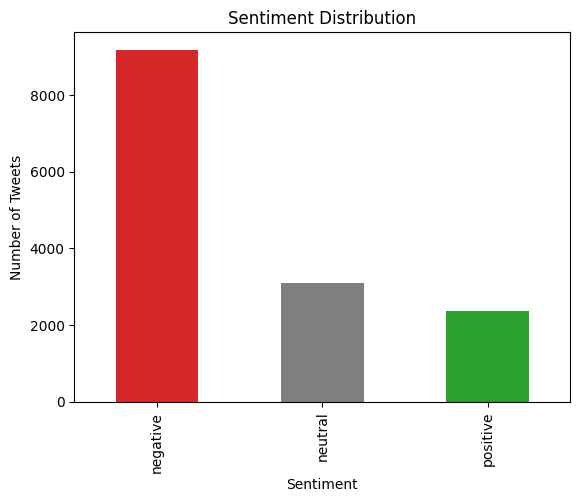

In [4]:
df["sentiment"].value_counts().plot(kind="bar", color=["#d62728", "#7f7f7f", "#2ca02c"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)          # remove @mentions
    text = re.sub(r"[^a-z\s]", "", text)       # remove special chars/numbers
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [6]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(11712,) (2928,)


In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7943989071038251
              precision    recall  f1-score   support

    negative       0.82      0.94      0.87      1835
     neutral       0.68      0.55      0.61       620
    positive       0.84      0.54      0.66       473

    accuracy                           0.79      2928
   macro avg       0.78      0.68      0.71      2928
weighted avg       0.79      0.79      0.78      2928



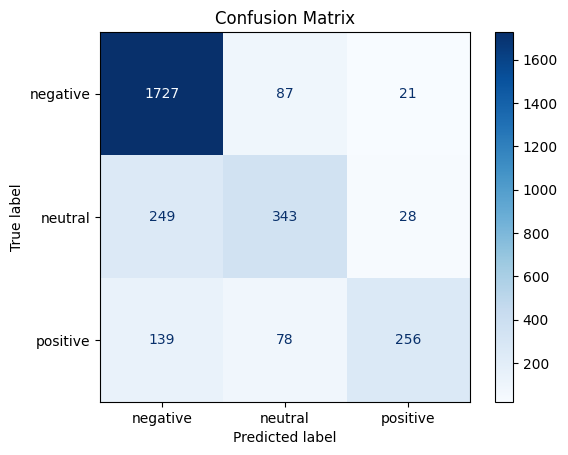

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
display.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [10]:
results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

errors = results[results["actual"] != results["predicted"]]

print("Total test samples:", len(results))
print("Incorrect predictions:", len(errors))
print("Error rate:", len(errors) / len(results))
errors.head(20)

Total test samples: 2928
Incorrect predictions: 602
Error rate: 0.20560109289617487


,text,actual,predicted
0,past,neutral,negative
1,would you say a delay is more likely thanks so...,positive,negative
6,this link in your tweet goes to someones inter...,neutral,negative
9,when will the flight resume i dons see it in t...,negative,neutral
18,well i did miss it but gate agents had rebooke...,positive,negative
33,such a bummer but i understand its a business ...,neutral,negative
48,how you like the redcarpet treatment,neutral,negative
53,i get amp can appreciate that ive just had so ...,negative,positive
54,i have d and d embossed badges and patches sup...,neutral,negative
55,i was under the impression when there is an ho...,neutral,negative


In [11]:
error_counts = errors.groupby(["actual", "predicted"]).size()
print(error_counts)

actual    predicted
negative  neutral       87
          positive      21
neutral   negative     249
          positive      28
positive  negative     139
          neutral       78
dtype: int64


In [12]:
neutral_errors = errors[errors["actual"] == "neutral"]
positive_errors = errors[errors["actual"] == "positive"]

print("Sample neutral misclassifications:")
print(neutral_errors.head(10))

print("\nSample positive misclassifications:")
print(positive_errors.head(10))

Sample neutral misclassifications:
                                                 text   actual predicted
0                                                past  neutral  negative
6   this link in your tweet goes to someones inter...  neutral  negative
33  such a bummer but i understand its a business ...  neutral  negative
48               how you like the redcarpet treatment  neutral  negative
54  i have d and d embossed badges and patches sup...  neutral  negative
55  i was under the impression when there is an ho...  neutral  negative
64  so what would be a file number that works need...  neutral  negative
70                      have five people shown up yet  neutral  negative
77                                      i already did  neutral  negative
95                        was in the air just dmd you  neutral  negative

Sample positive misclassifications:
                                                  text    actual predicted
1    would you say a delay is more likely thanks s

In [13]:
def predict_sentiment(sentence):
    cleaned = clean_text(sentence)
    vec = tfidf.transform([cleaned])
    return model.predict(vec)[0]

test_sentences = [
    "This airline was amazing, best flight ever",
    "The flight was delayed but the staff were fine",
    "I hated this flight, worst experience",
    "The movie was not bad at all",
    "Great, another delayed flight, love it",
]

for s in test_sentences:
    print(s, "->", predict_sentiment(s))

This airline was amazing, best flight ever -> positive
The flight was delayed but the staff were fine -> negative
I hated this flight, worst experience -> negative
The movie was not bad at all -> negative
Great, another delayed flight, love it -> positive


## Design Choices & Results

**Dataset:** Twitter US Airline Sentiment (Kaggle, 14,640 tweets) — chosen because it
already has the exact 3-class labels (positive/neutral/negative) this assignment needs,
and provides realistic, messy real-world text.

**Pipeline:** Text Cleaning (lowercase, URL removal, @mention removal, special-char
removal) → TF-IDF (unigram + bigram, max 5000 features) → Logistic Regression

**Class Distribution (imbalanced):**
- Negative: 9,178 (63%)
- Neutral: 3,099 (21%)
- Positive: 2,363 (16%)

**Results (80/20 stratified split):**
- Overall accuracy: 79.4%
- Negative F1: 0.87 (strong — majority class)
- Neutral F1: 0.61
- Positive F1: 0.66

**Error Analysis Findings:**
1. **Class imbalance bias** — the majority of neutral and positive errors are
   misclassified as negative (249 neutral→negative, 139 positive→negative),
   consistent with the model favoring the dominant training class.
2. **Negation errors** — e.g. "The movie was not bad at all" predicted negative
   despite being positive; the model weights "bad" without understanding "not bad".
3. **Sarcasm errors** — e.g. "Great, another delayed flight, love it" predicted
   positive; TF-IDF cannot detect sarcastic framing from word occurrence alone.
4. **Short/low-signal tweets** — very short neutral tweets ("past", "i already did")
   carry almost no sentiment vocabulary, making them inherently hard to classify.

**Possible Improvements:** class rebalancing (oversampling minority classes or
class-weighted Logistic Regression), bigram-aware negation handling, or a
transformer-based model (BERT) for better context understanding — all noted in
the brief as beyond this assignment's basic-NLP scope.